In [1]:
"""
InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation. 
StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product. 
Description: Product (item) name. Nominal. 
Quantity: The quantities of each product (item) per transaction. Numeric.	
InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated. 
UnitPrice: Unit price. Numeric. Product price per unit in sterling (Â£). 
CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer. 
Country: Country name. Nominal. The name of the country where a customer resides.
"""

"\nInvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation. \nStockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product. \nDescription: Product (item) name. Nominal. \nQuantity: The quantities of each product (item) per transaction. Numeric.\t\nInvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated. \nUnitPrice: Unit price. Numeric. Product price per unit in sterling (Â£). \nCustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer. \nCountry: Country name. Nominal. The name of the country where a customer resides.\n"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    silhouette_score
)
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import scipy as sp
from sklearn import tree , svm
from sklearn.tree import export_text
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier



In [3]:
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].dtype)

datetime64[ns]


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df.describe(include="O")

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [9]:
df[df['CustomerID'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


In [10]:
df[(df["Quantity"] < 0)& (df["CustomerID"].isna())].value_counts(df['Country'])

Country
United Kingdom    1659
EIRE                55
Hong Kong            4
Bahrain              1
Name: count, dtype: int64

In [11]:
df['invoiceNo'] = df['InvoiceNo'].astype(str)
df[df['invoiceNo'].str.match("^\\d{6}$")==False]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,invoiceNo
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,C536379
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,C536383
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,C536391
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,C536391
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,C536391
...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,C581490
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,C581499
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,C581568
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,C581569


In [12]:
df["invoiceNo"].str.replace(r"[0-9]", "", regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [13]:
df[df["invoiceNo"].str.contains("A")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,invoiceNo
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,A563185
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,A563186
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,A563187


In [14]:
df["StockCode"]=df["StockCode"].astype(str)
df[(df["StockCode"].str.match("^\\d{5}$")==False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$")==False)]["StockCode"].unique()

array(['POST', 'D', 'C2', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE',
       'DCGS0076', 'DCGS0003', 'gift_0001_40', 'DCGS0070', 'm',
       'gift_0001_50', 'gift_0001_30', 'gift_0001_20', 'DCGS0055',
       'DCGS0072', 'DCGS0074', 'DCGS0069', 'DCGS0057', 'DCGSSBOY',
       'DCGSSGIRL', 'gift_0001_10', 'PADS', 'DCGS0004', 'DCGS0073',
       'DCGS0071', 'DCGS0068', 'DCGS0067', 'DCGS0066P', 'B', 'CRUK'],
      dtype=object)

In [15]:
df[df['StockCode'].str.contains("^DOT")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,invoiceNo
1814,536544,DOT,DOTCOM POSTAGE,1,2010-12-01 14:32:00,569.77,NaN,United Kingdom,536544
3041,536592,DOT,DOTCOM POSTAGE,1,2010-12-01 17:06:00,607.49,NaN,United Kingdom,536592
5450,536862,DOT,DOTCOM POSTAGE,1,2010-12-03 11:13:00,254.43,NaN,United Kingdom,536862
5545,536864,DOT,DOTCOM POSTAGE,1,2010-12-03 11:27:00,121.06,NaN,United Kingdom,536864
5685,536865,DOT,DOTCOM POSTAGE,1,2010-12-03 11:28:00,498.47,NaN,United Kingdom,536865
...,...,...,...,...,...,...,...,...,...
536834,581219,DOT,DOTCOM POSTAGE,1,2011-12-08 09:28:00,1008.96,NaN,United Kingdom,581219
537254,581238,DOT,DOTCOM POSTAGE,1,2011-12-08 10:53:00,1683.75,NaN,United Kingdom,581238
539368,581439,DOT,DOTCOM POSTAGE,1,2011-12-08 16:30:00,938.59,NaN,United Kingdom,581439
540908,581492,DOT,DOTCOM POSTAGE,1,2011-12-09 10:03:00,933.17,NaN,United Kingdom,581492


Notes

Stock Code

StockCode is meant to follow the pattern [0-9]{5} but seems to have legit values for [0-9]{5}[a-zA-Z]+
Also contains other values: | Code | Description | Action | |---------------------|------------------------------------------------------------------------|-------------------------| | DCGS | Looks valid, some quantities are negative though and customer ID is null | Exclude from clustering | | D | Looks valid, represents discount values | Exclude from clustering | | DOT | Looks valid, represents postage charges | Exclude from clustering | | M or m | Looks valid, represents manual transactions | Exclude from clustering | | C2 | Carriage transaction - not sure what this means | Exclude from clustering | | C3 | Not sure, only 1 transaction | Exclude | | BANK CHARGES or B | Bank charges | Exclude from clustering | | S | Samples sent to customer | Exclude from clustering | | TESTXXX | Testing data, not valid | Exclude from clustering | | gift__XXX | Purchases with gift cards, might be interesting for another analysis, but no customer data | Exclude | | PADS | Looks like a legit stock code for padding | Include | | SP1002 | Looks like a special request item, only 2 transactions, 3 look legit, 1 has 0 pricing | Exclude for now| | AMAZONFEE | Looks like fees for Amazon shipping or something | Exclude for now | | ADJUSTX | Looks like manual account adjustments by admins | Exclude for now |

#Data Cleaning

In [16]:
cleaned_df = df.copy()

In [17]:
cleaned_df["invoiceNo"] = cleaned_df["invoiceNo"].astype("str")
mask = (
    cleaned_df["invoiceNo"].str.match("^\\d{6}$") == True 
)
cleaned_df = cleaned_df[mask]
cleaned_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,invoiceNo
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,536365
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,536365
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,581587
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,581587
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,581587
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,581587


In [18]:
cleaned_df["StockCode"] = cleaned_df["StockCode"].astype(str)
mask = (
      (cleaned_df["StockCode"].str.match("^\\d{5}$") == True) 
      |  (cleaned_df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == True)
      |  (cleaned_df["StockCode"].str.match("^PADS$") == True)    
)
cleaned_df = cleaned_df[mask]
cleaned_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,invoiceNo
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,536365
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,536365
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,581587
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,581587
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,581587
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,581587


In [19]:
cleaned_df.dropna(subset=['CustomerID'], inplace=True)

In [20]:
cleaned_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,396374.000000,396374,396374.000000,396374.000000
mean,13.046353,2011-07-11 00:04:48.847805440,2.867954,15301.603824
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-07 11:16:00,1.250000,13975.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:41:00,3.750000,16803.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,180.732689,NaN,4.264554,1709.976485


In [21]:
cleaned_df[cleaned_df["UnitPrice"] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,invoiceNo
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany,537197
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom,539263
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE,539722
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom,540372
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom,540372
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom,541109
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom,543599
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom,547417
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom,548318
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom,548871


In [22]:
len(cleaned_df[cleaned_df["UnitPrice"] == 0])

34

In [23]:
cleaned_df = cleaned_df [cleaned_df["UnitPrice"] > 0]
cleaned_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,396340.000000,396340,396340.000000,396340.000000
mean,13.012456,2011-07-11 00:04:40.164908544,2.868200,15301.689070
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:16:00,1.250000,13975.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:41:00,3.750000,16803.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,179.640568,NaN,4.264654,1709.957487


In [24]:
(len(cleaned_df)/len(df))

0.7313774083840645

Dropped about 27% of record

#Feature Engineering

In [25]:
cleaned_df['TotalPrice'] = cleaned_df['Quantity'] * cleaned_df['UnitPrice']
cleaned_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,invoiceNo,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,536365,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,536365,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365,20.34


In [26]:
aggregated_df = cleaned_df.groupby(by = 'CustomerID', as_index=False)\
    .agg(
        MonetaryValue = ('TotalPrice', 'sum'),
        frequency = ('InvoiceNo', 'nunique'),
        lastInvoiceDate = ('InvoiceDate', 'max')
    )
aggregated_df.head()   

,CustomerID,MonetaryValue,frequency,lastInvoiceDate
0,12346.0,77183.60,1,2011-01-18 10:01:00
1,12347.0,4310.00,7,2011-12-07 15:52:00
2,12348.0,1437.24,4,2011-09-25 13:13:00
3,12349.0,1457.55,1,2011-11-21 09:51:00
4,12350.0,294.40,1,2011-02-02 16:01:00


In [27]:
max_invoice_date = aggregated_df['lastInvoiceDate'].max()
aggregated_df["Recency"]=(max_invoice_date-aggregated_df["lastInvoiceDate"]).dt.days
aggregated_df.head()

,CustomerID,MonetaryValue,frequency,lastInvoiceDate,Recency
0,12346.0,77183.60,1,2011-01-18 10:01:00,325
1,12347.0,4310.00,7,2011-12-07 15:52:00,1
2,12348.0,1437.24,4,2011-09-25 13:13:00,74
3,12349.0,1457.55,1,2011-11-21 09:51:00,18
4,12350.0,294.40,1,2011-02-02 16:01:00,309


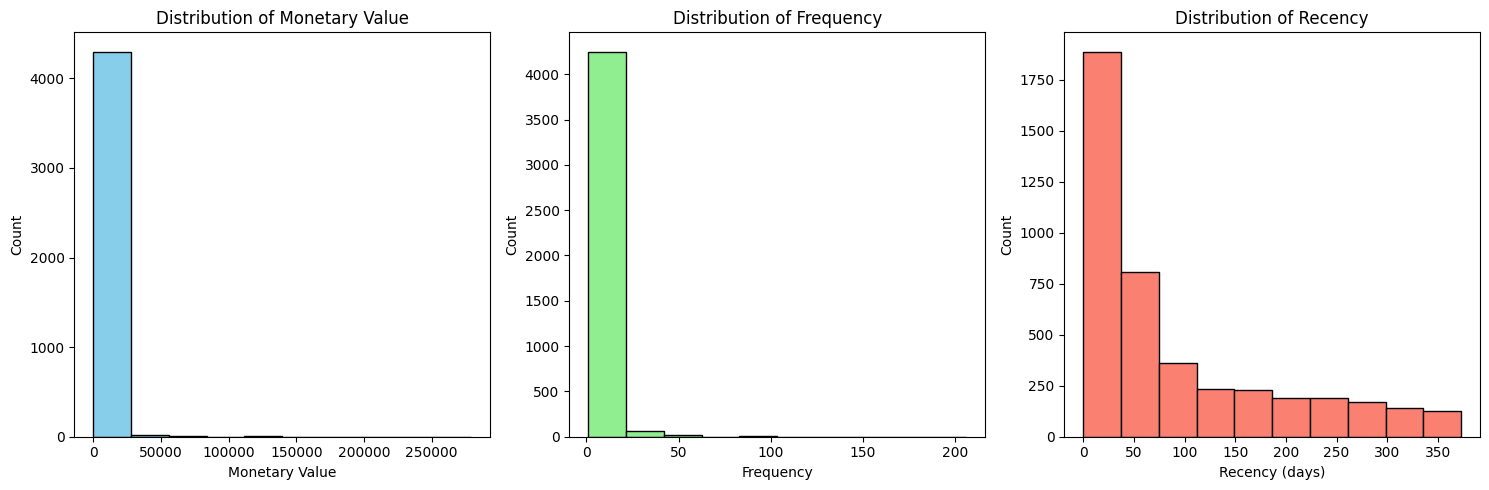

In [28]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(aggregated_df["MonetaryValue"], bins=10 , color='skyblue', edgecolor='black')
plt.title("Distribution of Monetary Value")
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
plt.hist(aggregated_df["frequency"], bins=10 , color='lightgreen', edgecolor='black')
plt.title("Distribution of Frequency")
plt.xlabel("Frequency") 
plt.ylabel("Count")

plt.subplot(1, 3, 3)
plt.hist(aggregated_df["Recency"], bins=10 , color='salmon', edgecolor='black')
plt.title("Distribution of Recency")
plt.xlabel("Recency (days)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

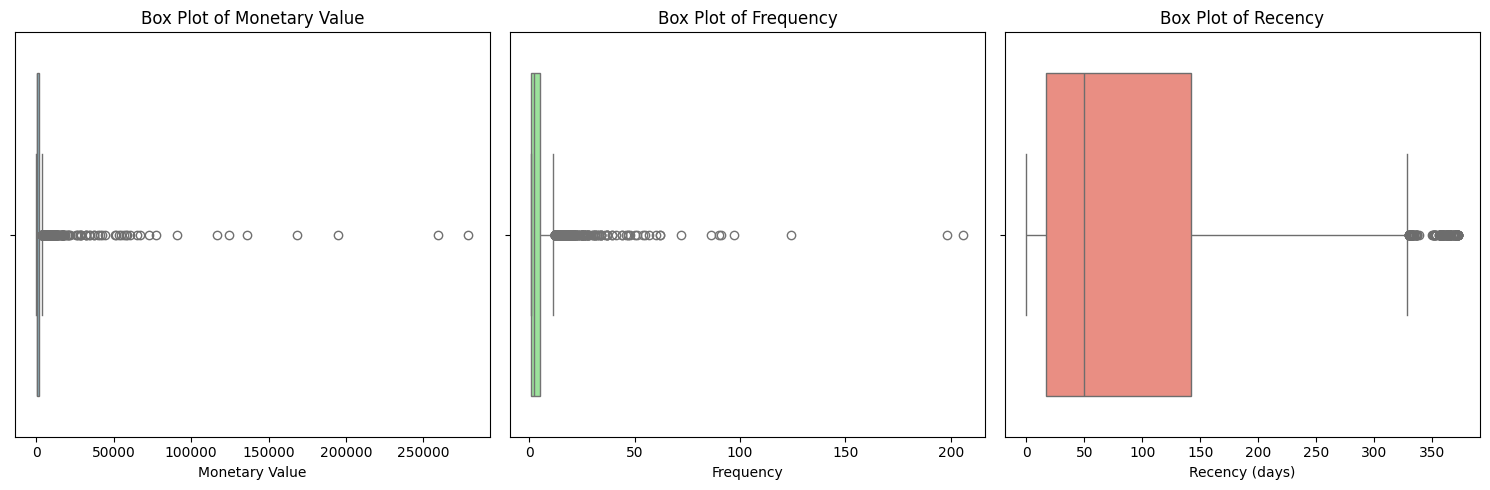

In [29]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x=aggregated_df["MonetaryValue"], color='skyblue')
plt.title("Box Plot of Monetary Value")
plt.xlabel("Monetary Value")

plt.subplot(1, 3, 2)
sns.boxplot(x=aggregated_df["frequency"], color='lightgreen')
plt.title("Box Plot of Frequency")
plt.xlabel("Frequency")

plt.subplot(1, 3, 3)
sns.boxplot(x=aggregated_df["Recency"], color='salmon')
plt.title("Box Plot of Recency")
plt.xlabel("Recency (days)")

plt.tight_layout()
plt.show()

In [30]:
Q1 = aggregated_df['MonetaryValue'].quantile(0.25)
Q3 = aggregated_df['MonetaryValue'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Monetry_outliers_df = aggregated_df[(aggregated_df['MonetaryValue'] < lower) | (aggregated_df['MonetaryValue'] > upper)].copy()

Monetry_outliers_df.describe()

,CustomerID,MonetaryValue,frequency,lastInvoiceDate,Recency
count,425.000000,425.000000,425.000000,425,425.000000
mean,15033.644706,12568.004141,16.647059,2011-11-14 08:29:09.741176576,24.724706
min,12346.000000,3622.680000,1.000000,2010-12-02 15:27:00,0.000000
25%,13324.000000,4359.320000,8.000000,2011-11-15 14:22:00,3.000000
50%,15005.000000,5891.610000,12.000000,2011-11-29 12:09:00,10.000000
75%,16655.000000,9430.520000,19.000000,2011-12-06 12:09:00,23.000000
max,18251.000000,279138.020000,206.000000,2011-12-09 12:49:00,371.000000
std,1797.854931,26097.899415,19.066978,NaN,47.076383


In [31]:

Q1 = aggregated_df['frequency'].quantile(0.25)
Q3 = aggregated_df['frequency'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Frequency_outliers_df = aggregated_df[(aggregated_df['frequency'] < lower) | (aggregated_df['frequency'] > upper)].copy()


Frequency_outliers_df.describe()

,CustomerID,MonetaryValue,frequency,lastInvoiceDate,Recency
count,278.000000,278.000000,278.000000,278,278.000000
mean,15355.669065,14488.006691,23.089928,2011-11-25 21:49:19.640287744,13.165468
min,12395.000000,1296.440000,12.000000,2010-12-02 15:27:00,0.000000
25%,13880.250000,4197.772500,13.000000,2011-11-23 20:17:15,2.000000
50%,15290.500000,6283.525000,17.000000,2011-12-03 13:42:00,5.500000
75%,16781.250000,11040.835000,25.000000,2011-12-07 12:15:30,15.000000
max,18283.000000,279138.020000,206.000000,2011-12-09 12:49:00,371.000000
std,1745.001840,30142.778160,21.166586,NaN,30.366616


In [32]:
non_outliers_df = aggregated_df[
    (~aggregated_df.index.isin(Monetry_outliers_df.index)) &
    (~aggregated_df.index.isin(Frequency_outliers_df.index)
       )]
non_outliers_df.describe()

,CustomerID,MonetaryValue,frequency,lastInvoiceDate,Recency
count,3863.000000,3863.000000,3863.000000,3863,3863.000000
mean,15323.852705,853.814417,2.755113,2011-08-31 01:42:04.721718784,99.943826
min,12348.000000,3.750000,1.000000,2010-12-01 09:53:00,0.000000
25%,13850.500000,278.500000,1.000000,2011-07-01 15:21:00,21.000000
50%,15333.000000,570.460000,2.000000,2011-10-11 14:24:00,58.000000
75%,16798.000000,1187.005000,4.000000,2011-11-17 13:39:00,160.000000
max,18287.000000,3619.170000,11.000000,2011-12-09 12:50:00,373.000000
std,1709.731704,794.608100,2.168124,NaN,101.866688


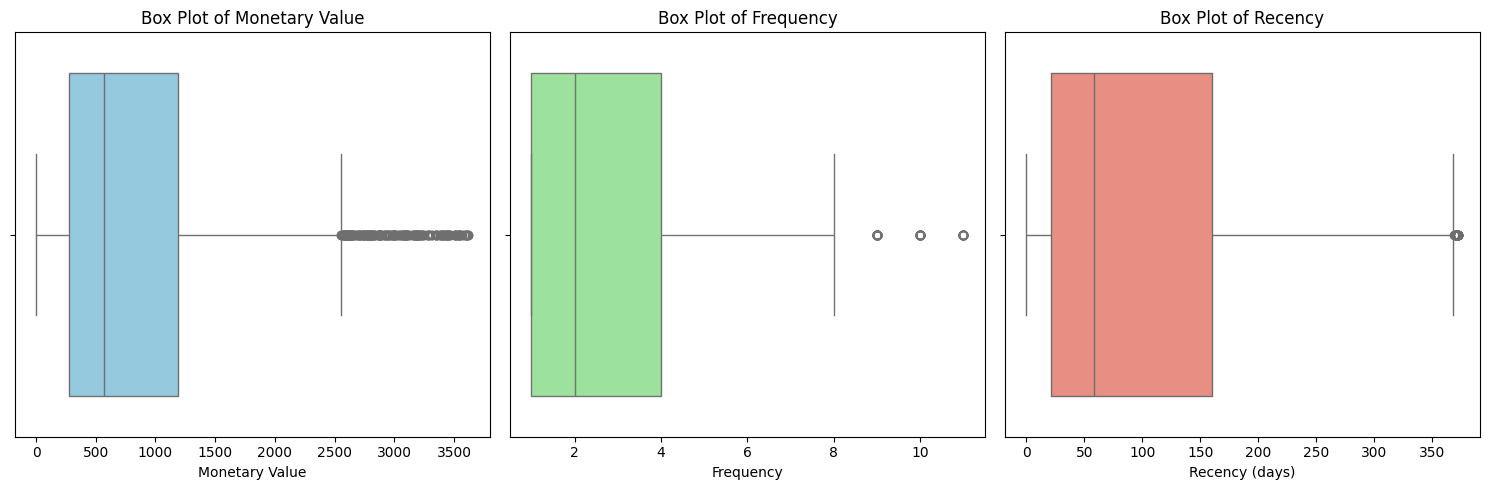

In [33]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x=non_outliers_df["MonetaryValue"], color='skyblue')
plt.title("Box Plot of Monetary Value")
plt.xlabel("Monetary Value")

plt.subplot(1, 3, 2)
sns.boxplot(x=non_outliers_df["frequency"], color='lightgreen')
plt.title("Box Plot of Frequency")
plt.xlabel("Frequency")

plt.subplot(1, 3, 3)
sns.boxplot(x=non_outliers_df["Recency"], color='salmon')
plt.title("Box Plot of Recency")
plt.xlabel("Recency (days)")

plt.tight_layout()
plt.show()

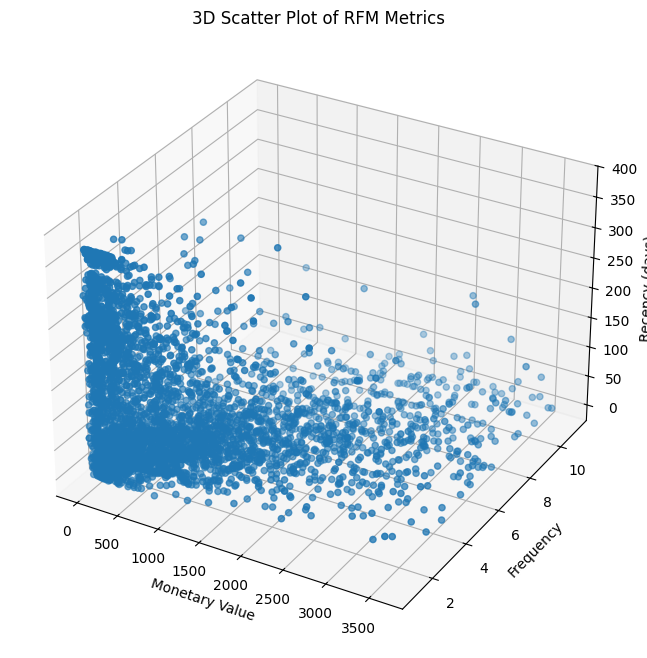

In [34]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(non_outliers_df['MonetaryValue'], non_outliers_df['frequency'], non_outliers_df['Recency'])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency (days)')
ax.set_title('3D Scatter Plot of RFM Metrics')

plt.show()

In [35]:
scaler = StandardScaler()
scaled_data  = scaler.fit_transform(non_outliers_df[['MonetaryValue', 'frequency', 'Recency']])
scaled_data

array([[ 0.73432565,  0.57425162, -0.25471707],
       [ 0.75988873, -0.8096124 , -0.80452635],
       [-0.70410412, -0.8096124 ,  2.05251827],
       ...,
       [-0.97292551, -0.8096124 ,  0.78599334],
       [-0.85054746, -0.34832439, -0.9125246 ],
       [ 1.23783397,  0.11296362, -0.5688938 ]])

In [36]:
scaled_data_df = pd.DataFrame(scaled_data , index = non_outliers_df.index, columns=['MonetaryValue', 'frequency', 'Recency'])
scaled_data_df

,MonetaryValue,frequency,Recency
2,0.734326,0.574252,-0.254717
3,0.759889,-0.809612,-0.804526
4,-0.704104,-0.809612,2.052518
5,0.669505,1.958116,-0.637620
6,-0.962630,-0.809612,1.011808
...,...,...,...
4328,-0.855771,-0.809612,-0.264535
4329,-0.847338,-0.809612,1.738342
4330,-0.972926,-0.809612,0.785993
4331,-0.850547,-0.348324,-0.912525


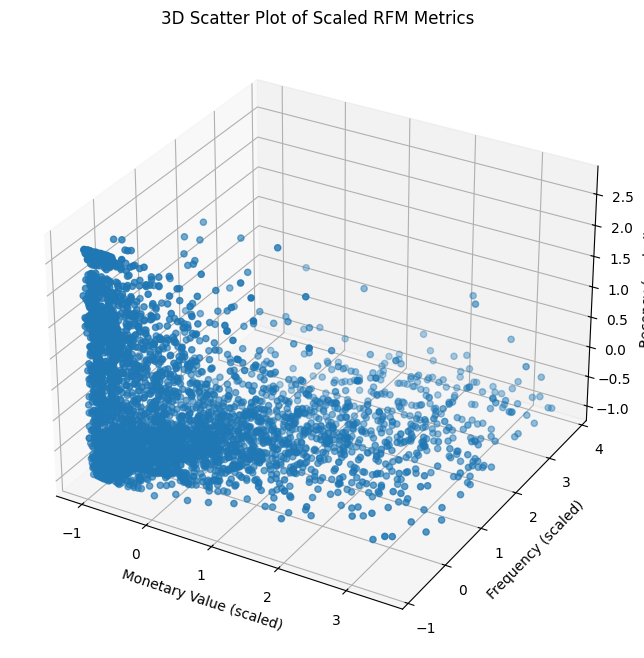

In [37]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(scaled_data_df['MonetaryValue'], scaled_data_df['frequency'], scaled_data_df['Recency'])

ax.set_xlabel('Monetary Value (scaled)')
ax.set_ylabel('Frequency (scaled)')
ax.set_zlabel('Recency (scaled)')
ax.set_title('3D Scatter Plot of Scaled RFM Metrics')

plt.show()

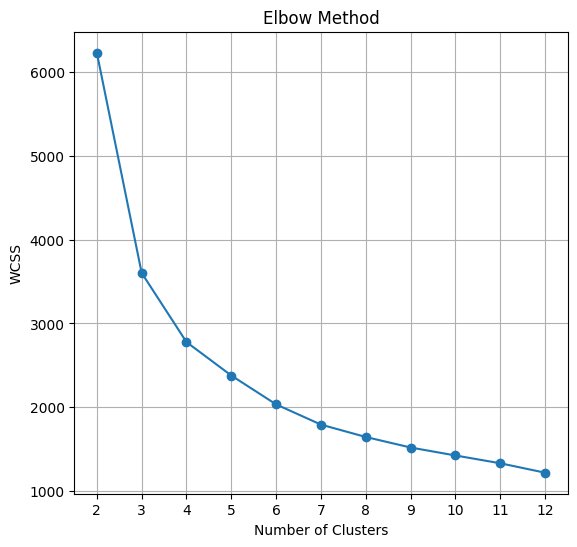

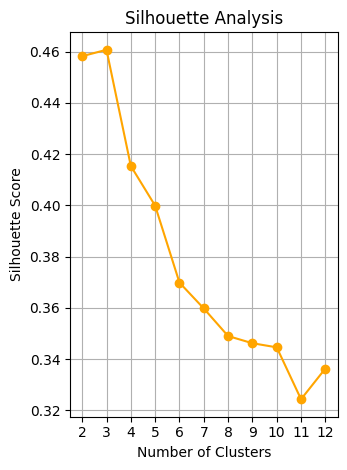

In [38]:
# import matplotlib.pyplot as plt
max_k = 12
wcss = []

siloutte_scores = []

for i in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, max_iter=1000)
    cluster_labels = kmeans.fit_predict(scaled_data_df)
    sil_score = silhouette_score(scaled_data_df, cluster_labels)
    siloutte_scores.append(sil_score)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
plt.plot(range(2,max_k + 1), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(2, max_k + 1))
plt.grid(True)
plt.show()

plt.subplot(1, 2, 2)
plt.plot(range(2, max_k + 1), siloutte_scores, marker='o', color='orange')
plt.title('Silhouette Analysis')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_k + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

### Silhouette Score

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Where:
- $s(i)$ is the silhouette score for a single sample $i$
- $a(i)$ is the average distance between $i$ and all other points in the same cluster,
- $b(i)$ is the minimum average distance between $i$ and all points in the nearest cluster to which $i$ does not belong.

The silhoutte score ranges between $[-1, 1]$, a higher value indicates more distinct clusters.

In [39]:
kmeans = KMeans(n_clusters=4, random_state=42, max_iter=1000)

clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataset
non_outliers_df['Cluster'] = clusters

In [40]:
non_outliers_df.head()

,CustomerID,MonetaryValue,frequency,lastInvoiceDate,Recency,Cluster
2,12348.0,1437.24,4,2011-09-25 13:13:00,74,3
3,12349.0,1457.55,1,2011-11-21 09:51:00,18,0
4,12350.0,294.40,1,2011-02-02 16:01:00,309,1
5,12352.0,1385.74,7,2011-11-03 14:37:00,35,2
6,12353.0,89.00,1,2011-05-19 17:47:00,203,1


In [41]:
non_outliers_df['Cluster'].value_counts()

Cluster
0    1549
1     942
3     890
2     482
Name: count, dtype: int64

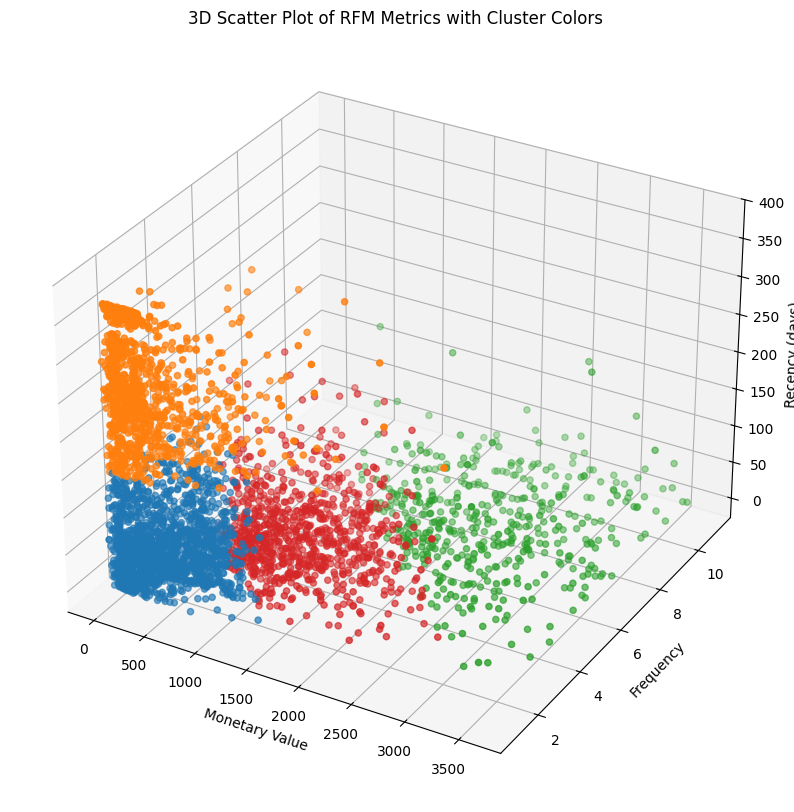

In [42]:
cluster_colors = {
    0:'#1f77b4',# Blue
    1:'#ff7f0e',# Orange
    2:'#2ca02c',# Green
    3:'#d62728' # Red
}

colors = non_outliers_df['Cluster'].map(cluster_colors)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(non_outliers_df['MonetaryValue'],
                     non_outliers_df['frequency'],
                     non_outliers_df['Recency'], 
                     c=colors,
                     marker='o',)

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency (days)')
ax.set_title('3D Scatter Plot of RFM Metrics with Cluster Colors')
plt.show()

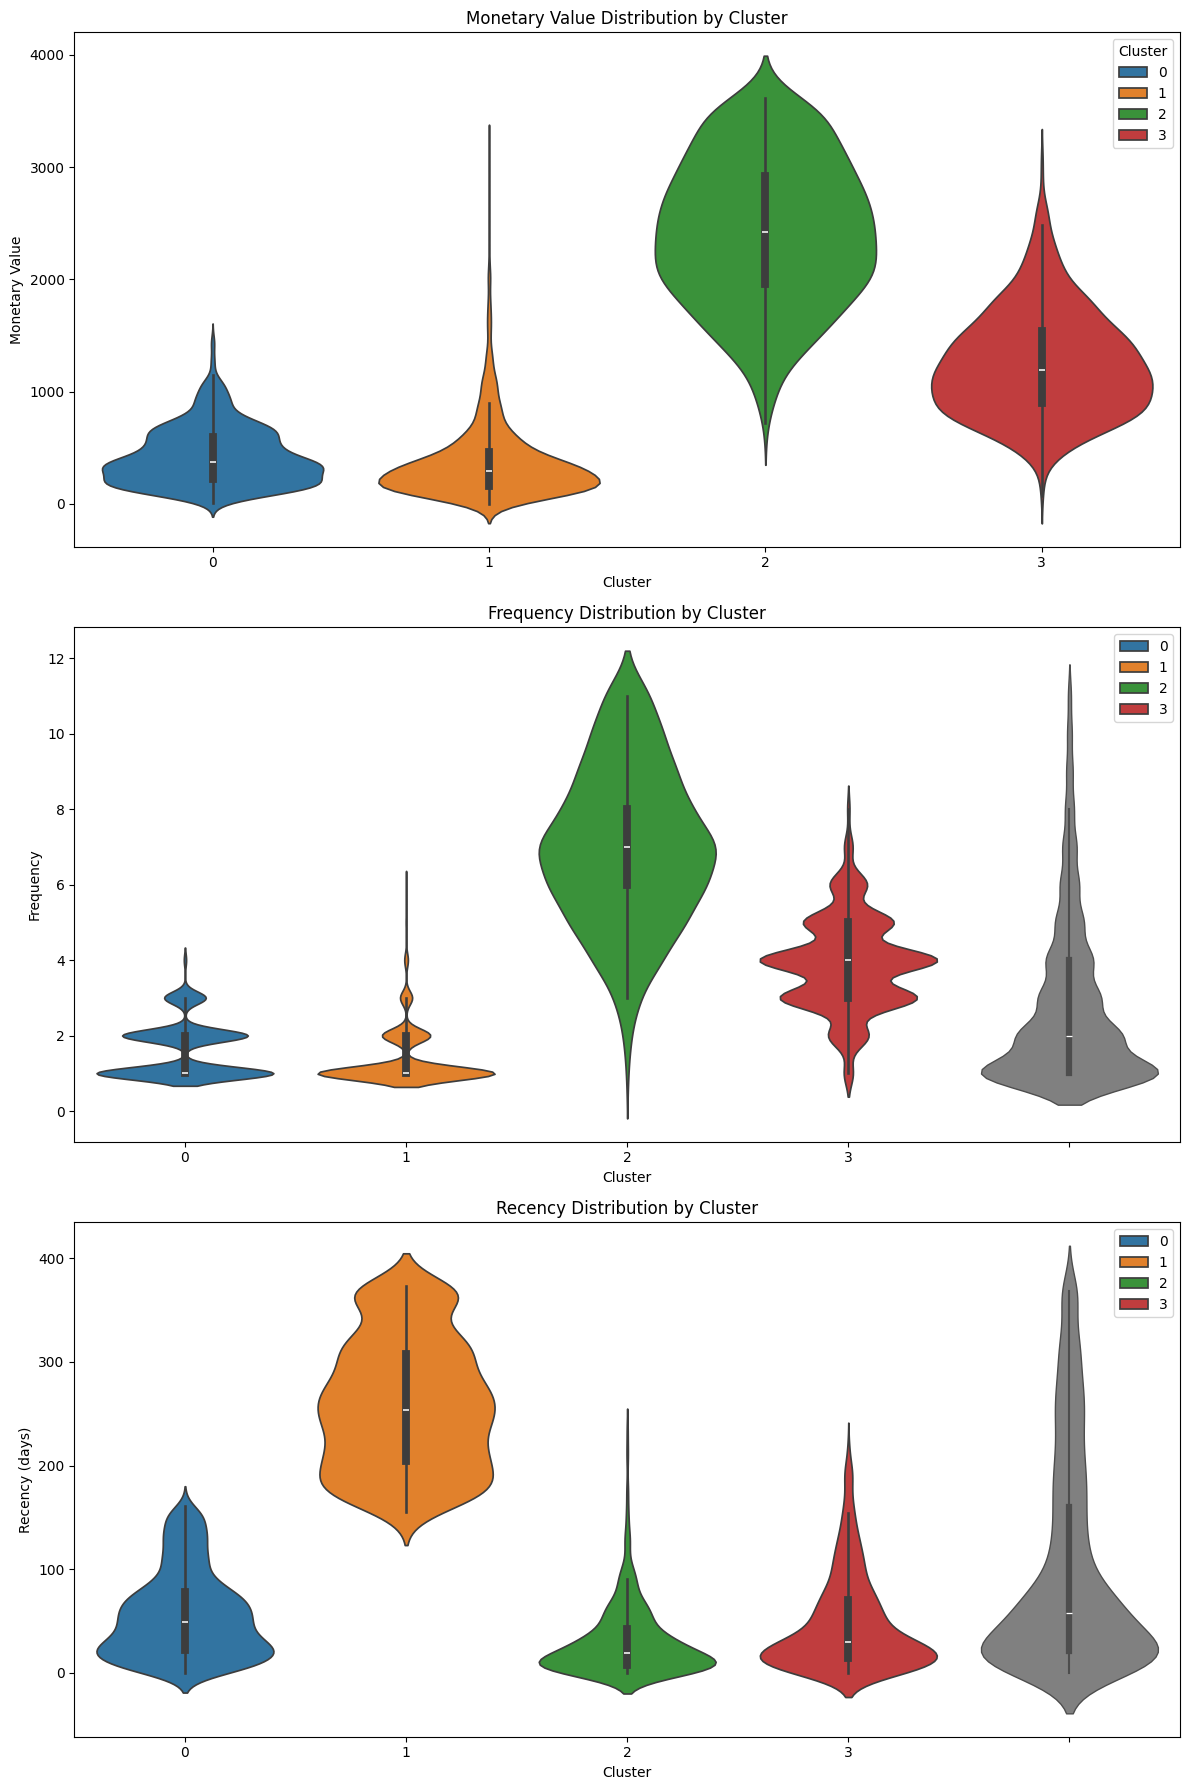

In [43]:
plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['MonetaryValue'], palette=cluster_colors,hue =non_outliers_df['Cluster'])
sns.violinplot(y_test = non_outliers_df["MonetaryValue"], color='gray',linewidth=1)
plt.title('Monetary Value Distribution by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['frequency'], palette=cluster_colors,hue =non_outliers_df['Cluster'])
sns.violinplot(y = non_outliers_df["frequency"], color='gray',linewidth=1)
plt.title('Frequency Distribution by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Recency'], palette=cluster_colors,hue =non_outliers_df['Cluster'])
sns.violinplot(y= non_outliers_df["Recency"], color='gray',linewidth=1)
plt.title('Recency Distribution by Cluster')
plt.ylabel('Recency (days)')

plt.tight_layout()
plt.show()

1. Cluster 0 (Blue): "Retain"
* Rationale: This cluster represents high-value customers who purchase regularly, though not always very recently. The focus should be on retention efforts to maintain their loyalty and spending levels.
* Action: Implement loyalty programs, personalized offers, and regular engagement to ensure they remain active.

2. Cluster 1 (Orange): "Re-Engage"
* Rationale: This group includes lower-value, infrequent buyers who haven’t purchased recently. The focus should be on re-engagement to bring them back into active purchasing behavior.
* Action: Use targeted marketing campaigns, special discounts, or reminders to encourage them to return and purchase again.

3. Cluster 2 (Green): "Nurture"
* Rationale: This cluster represents the least active and lowest-value customers, but they have made recent purchases. These customers may be new or need nurturing to increase their engagement and spending.
* Action: Focus on building relationships, providing excellent customer service, and offering incentives to encourage more frequent purchases.

4. Cluster 3 (Red): "Reward"
* Rationale: This cluster includes high-value, very frequent buyers, many of whom are still actively purchasing. They are your most loyal customers, and rewarding their loyalty is key to maintaining their engagement.
* Action: Implement a robust loyalty program, provide exclusive offers, and recognize their loyalty to keep them engaged and satisfied.

**Summary of Cluster Names:**

* Cluster 0 (Blue): "Retain"
* Cluster 1 (Orange): "Re-Engage"
* Cluster 2 (Green): "Nurture"
* Cluster 3 (Red): "Reward"

In [44]:
overlap_indices = Monetry_outliers_df.index.intersection(Frequency_outliers_df.index)

monetry_outliers_only = Monetry_outliers_df.drop(index=overlap_indices)
frequency_outliers_only = Frequency_outliers_df.drop(index=overlap_indices)
monetry_and_frequency_outliers = Monetry_outliers_df.loc[overlap_indices]

monetry_outliers_only["Cluster"] = -1
frequency_outliers_only["Cluster"] = -2
monetry_and_frequency_outliers["Cluster"] = -3


outlier_Clusters_df = pd.concat([monetry_outliers_only, frequency_outliers_only, monetry_and_frequency_outliers], ignore_index=True)
outlier_Clusters_df

,CustomerID,MonetaryValue,frequency,lastInvoiceDate,Recency,Cluster
0,12346.0,77183.60,1,2011-01-18 10:01:00,325,-1
1,12347.0,4310.00,7,2011-12-07 15:52:00,1,-1
2,12357.0,6207.67,1,2011-11-06 16:07:00,32,-1
3,12359.0,6372.58,4,2011-10-13 12:47:00,57,-1
4,12362.0,4737.23,10,2011-12-06 15:40:00,2,-1
...,...,...,...,...,...,...
466,18172.0,7561.68,20,2011-11-25 11:12:00,14,-3
467,18198.0,5425.56,17,2011-12-05 14:49:00,3,-3
468,18223.0,6484.54,14,2011-12-05 09:11:00,4,-3
469,18225.0,5509.12,12,2011-12-06 13:27:00,2,-3


In [45]:
outlier_Clusters_df['Cluster'].value_counts()

Cluster
-3    232
-1    193
-2     46
Name: count, dtype: int64

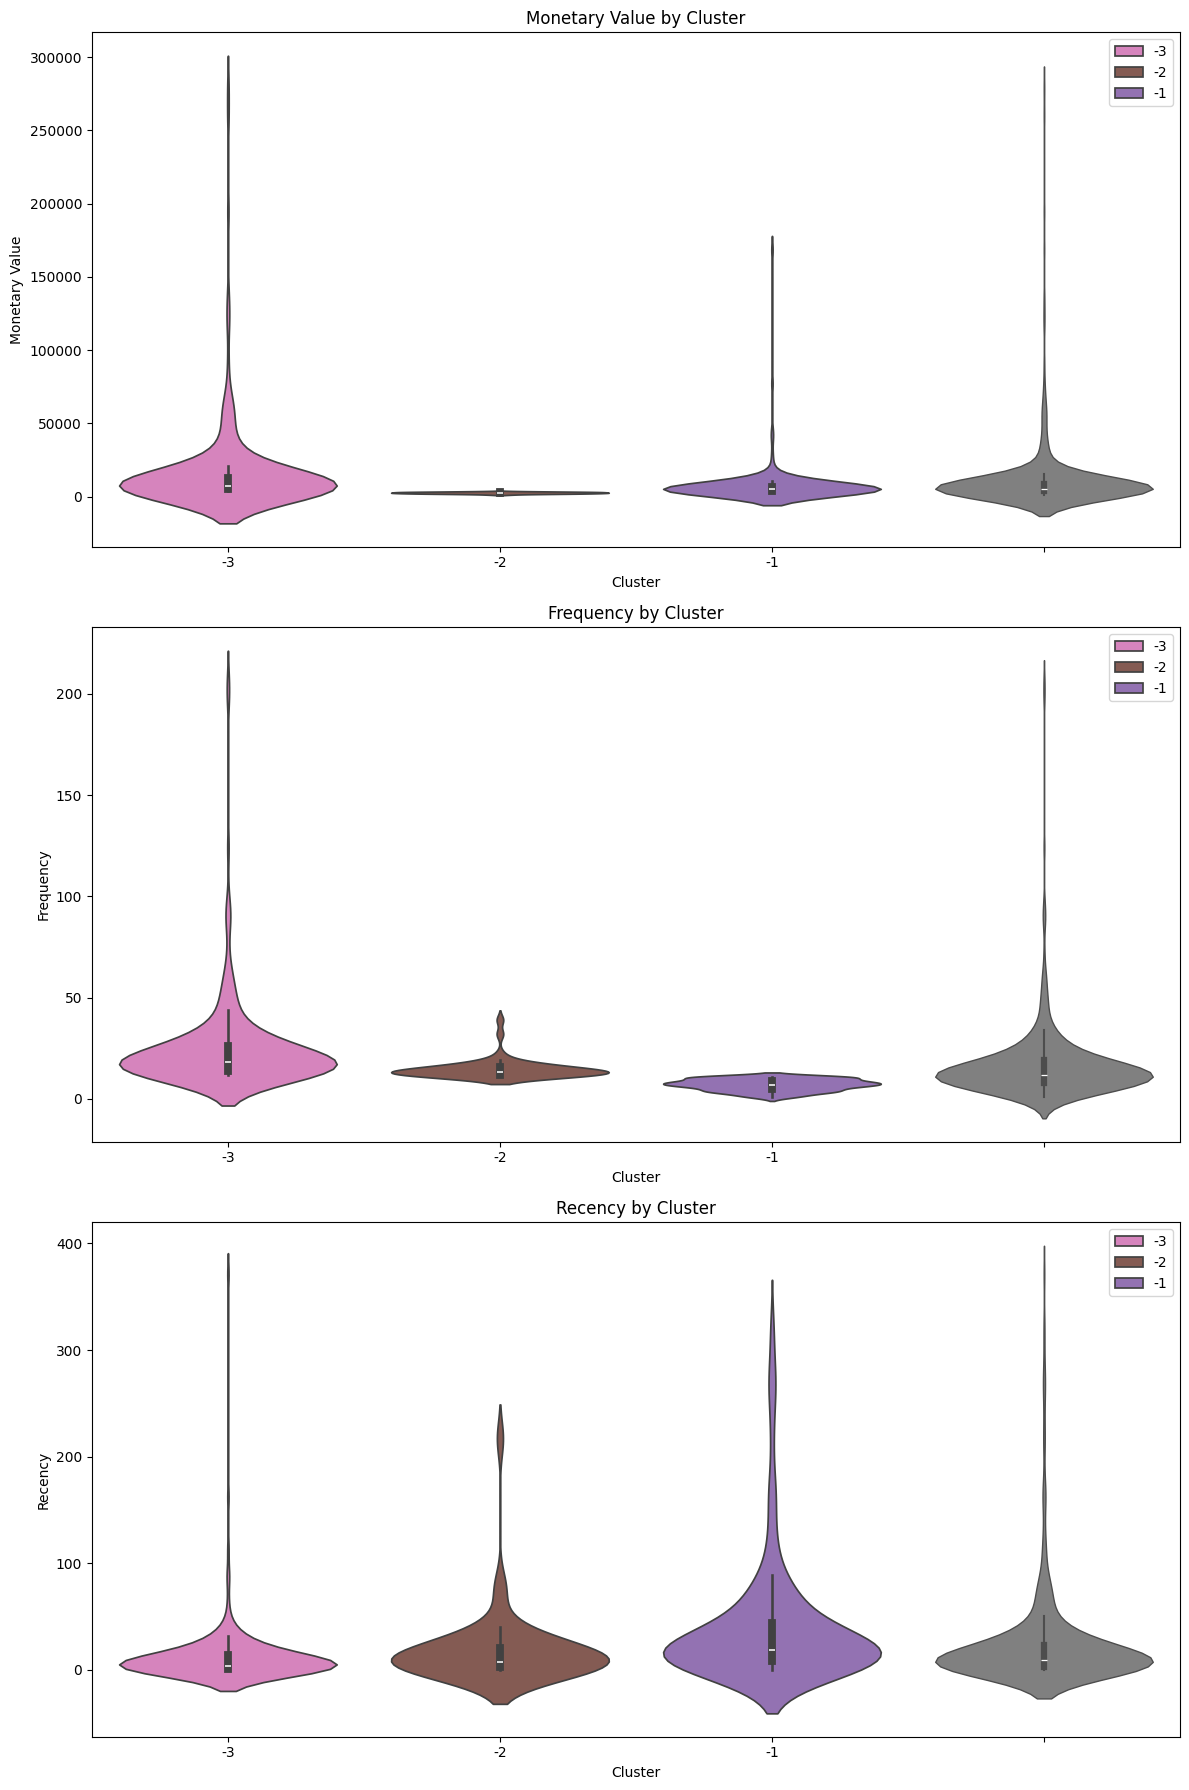

In [46]:
cluster_colors = {-1: '#9467bd',
                  -2: '#8c564b',
                  -3: '#e377c2'}

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=outlier_Clusters_df['Cluster'], y=outlier_Clusters_df['MonetaryValue'], palette=cluster_colors, hue=outlier_Clusters_df["Cluster"])
sns.violinplot(y=outlier_Clusters_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=outlier_Clusters_df['Cluster'], y=outlier_Clusters_df['frequency'], palette=cluster_colors, hue=outlier_Clusters_df["Cluster"])
sns.violinplot(y=outlier_Clusters_df['frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=outlier_Clusters_df['Cluster'], y=outlier_Clusters_df['Recency'], palette=cluster_colors, hue=outlier_Clusters_df["Cluster"])
sns.violinplot(y=outlier_Clusters_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

* Cluster -1 (Monetary Outliers) PAMPER:
Characteristics: High spenders but not necessarily frequent buyers. Their purchases are large but infrequent.
Potential Strategy: Focus on maintaining their loyalty with personalized offers or luxury services that cater to their high spending capacity.

* Cluster -2 (Frequency Outliers) UPSELL:
Characteristics: Frequent buyers who spend less per purchase. These customers are consistently engaged but might benefit from upselling opportunities.
Potential Strategy: Implement loyalty programs or bundle deals to encourage higher spending per visit, given their frequent engagement.

* Cluster -3 (Monetary & Frequency Outliers) DELIGHT:
Characteristics: The most valuable outliers, with extreme spending and frequent purchases. They are likely your top-tier customers who require special attention.
Potential Strategy: Develop VIP programs or exclusive offers to maintain their loyalty and encourage continued engagement.

In [47]:
cluster_labels = {
    0: "RETAIN",
    1: "RE-ENGAGE",
    2: "NURTURE",
    3: "REWARD",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}

In [48]:
full_clustering_df = pd.concat([non_outliers_df, outlier_Clusters_df])

full_clustering_df

,CustomerID,MonetaryValue,frequency,lastInvoiceDate,Recency,Cluster
2,12348.0,1437.24,4,2011-09-25 13:13:00,74,3
3,12349.0,1457.55,1,2011-11-21 09:51:00,18,0
4,12350.0,294.40,1,2011-02-02 16:01:00,309,1
5,12352.0,1385.74,7,2011-11-03 14:37:00,35,2
6,12353.0,89.00,1,2011-05-19 17:47:00,203,1
...,...,...,...,...,...,...
466,18172.0,7561.68,20,2011-11-25 11:12:00,14,-3
467,18198.0,5425.56,17,2011-12-05 14:49:00,3,-3
468,18223.0,6484.54,14,2011-12-05 09:11:00,4,-3
469,18225.0,5509.12,12,2011-12-06 13:27:00,2,-3


In [49]:
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)

full_clustering_df

,CustomerID,MonetaryValue,frequency,lastInvoiceDate,Recency,Cluster,ClusterLabel
2,12348.0,1437.24,4,2011-09-25 13:13:00,74,3,REWARD
3,12349.0,1457.55,1,2011-11-21 09:51:00,18,0,RETAIN
4,12350.0,294.40,1,2011-02-02 16:01:00,309,1,RE-ENGAGE
5,12352.0,1385.74,7,2011-11-03 14:37:00,35,2,NURTURE
6,12353.0,89.00,1,2011-05-19 17:47:00,203,1,RE-ENGAGE
...,...,...,...,...,...,...,...
466,18172.0,7561.68,20,2011-11-25 11:12:00,14,-3,DELIGHT
467,18198.0,5425.56,17,2011-12-05 14:49:00,3,-3,DELIGHT
468,18223.0,6484.54,14,2011-12-05 09:11:00,4,-3,DELIGHT
469,18225.0,5509.12,12,2011-12-06 13:27:00,2,-3,DELIGHT


## Visualisation

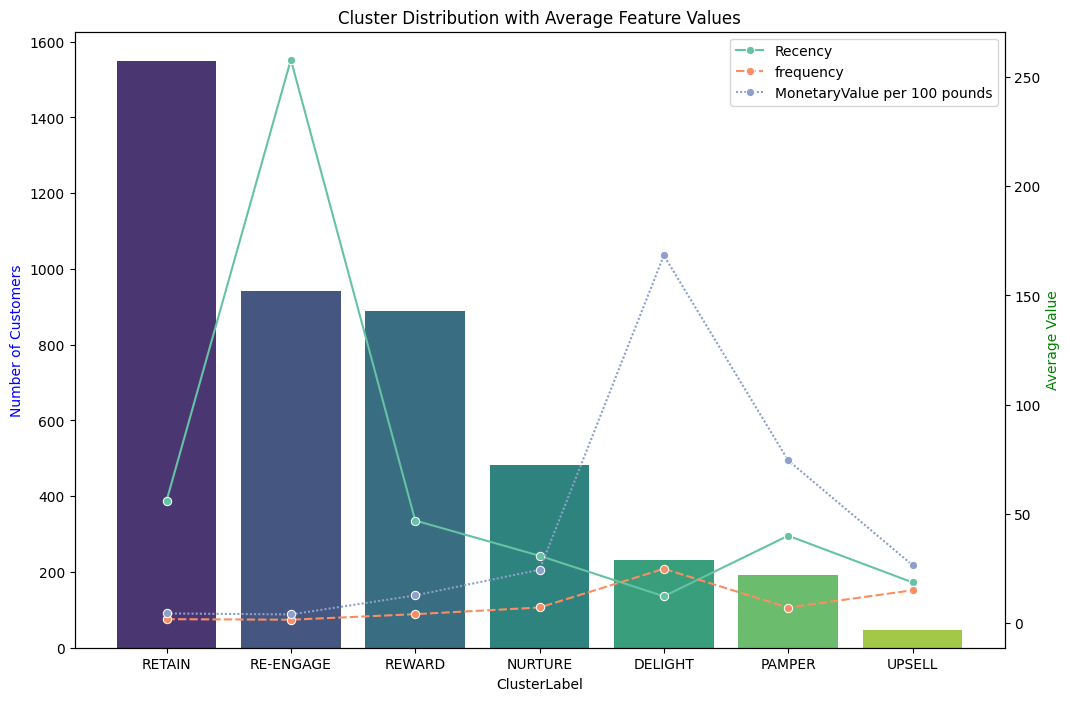

In [50]:
cluster_counts = full_clustering_df['ClusterLabel'].value_counts()
full_clustering_df["MonetaryValue per 100 pounds"] = full_clustering_df["MonetaryValue"] / 100.00
feature_means = full_clustering_df.groupby('ClusterLabel')[['Recency', 'frequency', 'MonetaryValue per 100 pounds']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Average Value', color='g')

plt.show()

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_data,
    non_outliers_df['Cluster'],
    test_size=0.2,
    random_state=42,
    stratify=non_outliers_df['Cluster']
)

In [52]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [53]:
y_pred = rf.predict(X_test)

In [54]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.9870633893919794


In [55]:
confusion_matrix(y_test, y_pred)

array([[308,   1,   0,   1],
       [  0, 187,   0,   2],
       [  0,   0,  92,   4],
       [  0,   1,   1, 176]], dtype=int64)

In [56]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      0.99      1.00       310\n           1       0.99      0.99      0.99       189\n           2       0.99      0.96      0.97        96\n           3       0.96      0.99      0.98       178\n\n    accuracy                           0.99       773\n   macro avg       0.99      0.98      0.98       773\nweighted avg       0.99      0.99      0.99       773\n'

<Figure size 600x400 with 0 Axes>

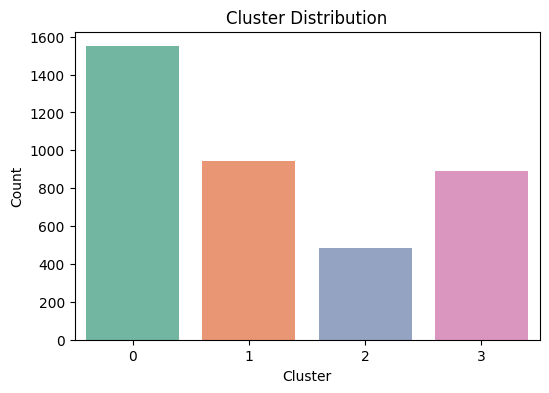

In [57]:
plt.figure(figsize=(6,4))

plt.figure(figsize=(6,4))
sns.countplot(x='Cluster', data=non_outliers_df, palette='Set2')
plt.title('Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()



In [58]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [59]:
y_pred_knn = knn.predict(scaled_data)

In [60]:
y_pred_knn = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print('KNN Accuracy:', knn_accuracy)

KNN Accuracy: 0.9870633893919794


In [61]:
y_pred_knn = knn.predict(X_test)
confusion_matrix(y_test, y_pred_knn)

array([[306,   1,   0,   3],
       [  4, 185,   0,   0],
       [  0,   0,  95,   1],
       [  0,   0,   1, 177]], dtype=int64)

In [62]:
classification_report(y_test, y_pred_knn)

'              precision    recall  f1-score   support\n\n           0       0.99      0.99      0.99       310\n           1       0.99      0.98      0.99       189\n           2       0.99      0.99      0.99        96\n           3       0.98      0.99      0.99       178\n\n    accuracy                           0.99       773\n   macro avg       0.99      0.99      0.99       773\nweighted avg       0.99      0.99      0.99       773\n'

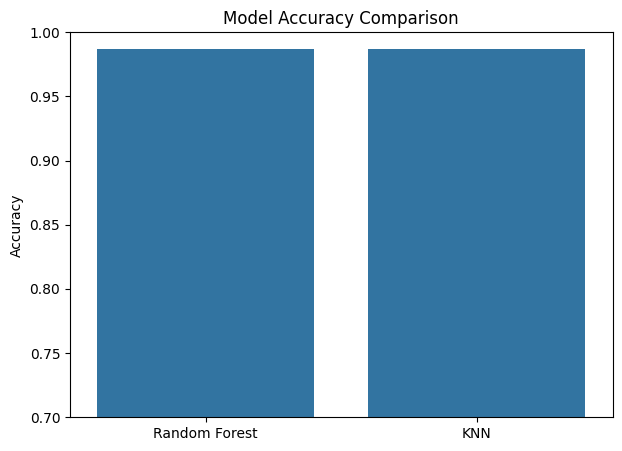

In [63]:
models = ['Random Forest', 'KNN']
accuracies = [accuracy, knn_accuracy]

plt.figure(figsize=(7,5))

sns.barplot(x=models, y=accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.show()

In [64]:
# Random Forest
rf_mse = mean_squared_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)
rf_mae = mean_absolute_error(y_test, y_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest R2 Score:", rf_r2)
print("--------------------------------------------------")
# KNN
knn_mse = mean_squared_error(y_test, y_pred_knn)
knn_r2 = r2_score(y_test, y_pred_knn)
knn_mae = mean_absolute_error(y_test, y_pred_knn)

print("KNN MAE:", knn_mae)
print("KNN MSE:", knn_mse)
print("KNN R2 Score:", knn_r2)

Random Forest MAE: 0.019404915912031046
Random Forest MSE: 0.03492884864165589
Random Forest R2 Score: 0.9752727918962146
--------------------------------------------------
KNN MAE: 0.02069857697283312
KNN MSE: 0.04398447606727038
KNN R2 Score: 0.9688620342396778


In [65]:
try_tree= tree.DecisionTreeClassifier()
try_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [66]:
try_tree_pred = try_tree.predict(X_test)

In [67]:
try_tree_pred = try_tree.predict(X_test)

In [68]:
try_tree_accuracy = accuracy_score(y_test, try_tree_pred)
print('Decision Tree Accuracy:', try_tree_accuracy)

Decision Tree Accuracy: 0.9831824062095731


In [69]:
plt.figure(figsize=(200,160),dpi=150)
tree.plot_tree(try_tree)

[Text(0.56640625, 0.9583333333333334, 'x[2] <= 0.565\ngini = 0.711\nsamples = 3090\nvalue = [1239, 753, 386, 712]'),
 Text(0.2602796052631579, 0.875, 'x[1] <= -0.118\ngini = 0.598\nsamples = 2310\nvalue = [1236, 6, 381, 687]'),
 Text(0.413342927631579, 0.9166666666666667, 'True  '),
 Text(0.10526315789473684, 0.7916666666666666, 'x[0] <= 0.357\ngini = 0.123\nsamples = 1163\nvalue = [1087, 6, 1, 69]'),
 Text(0.05263157894736842, 0.7083333333333334, 'x[2] <= 0.545\ngini = 0.011\nsamples = 1082\nvalue = [1076, 6, 0, 0]'),
 Text(0.02631578947368421, 0.625, 'x[2] <= 0.536\ngini = 0.002\nsamples = 1071\nvalue = [1070, 1, 0, 0]'),
 Text(0.013157894736842105, 0.5416666666666666, 'gini = 0.0\nsamples = 1066\nvalue = [1066, 0, 0, 0]'),
 Text(0.039473684210526314, 0.5416666666666666, 'x[0] <= -0.974\ngini = 0.32\nsamples = 5\nvalue = [4, 1, 0, 0]'),
 Text(0.02631578947368421, 0.4583333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0, 0]'),
 Text(0.05263157894736842, 0.4583333333333333, 'gini

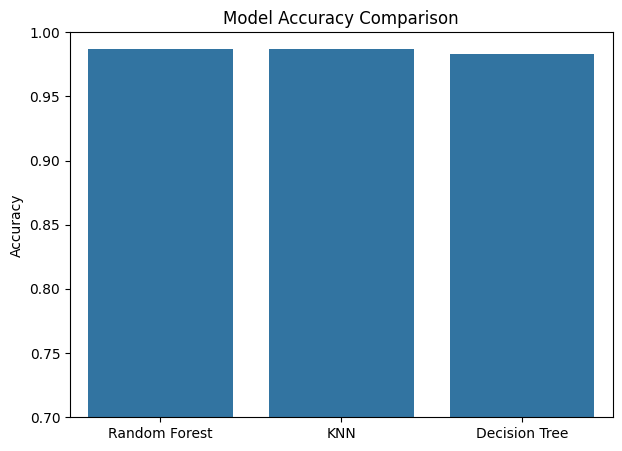

In [70]:
models = ['Random Forest', 'KNN',"Decision Tree"]
accuracies = [accuracy, knn_accuracy, try_tree_accuracy]

plt.figure(figsize=(7,5))

sns.barplot(x=models, y=accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.show()

In [71]:
svm_model = svm.SVC(kernel='linear', C=1, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

SVC(C=1, kernel='linear', random_state=42)

In [72]:
y_pred_svm = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print('SVM Accuracy:', svm_accuracy)

SVM Accuracy: 0.9961190168175937


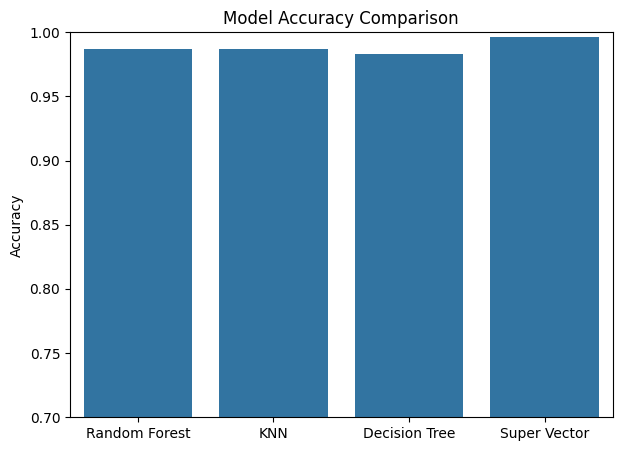

Random Forest : 0.9870633893919794
KNN : 0.9870633893919794 
Decision Tree : 0.9831824062095731
Super Vector: 0.9961190168175937


In [73]:
models = ['Random Forest', 'KNN',"Decision Tree","Super Vector"]
accuracies = [accuracy, knn_accuracy, try_tree_accuracy,svm_accuracy]

plt.figure(figsize=(7,5))

sns.barplot(x=models, y=accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.show()
print(f"Random Forest : {accuracy}") 
print(f"KNN : {knn_accuracy} ")
print(f"Decision Tree : {try_tree_accuracy}")
print(f"Super Vector: {svm_accuracy}")


In [75]:
rf = RandomForestClassifier(random_state=42)

rf = RandomForestClassifier(random_state=42)

X = scaled_data
y = non_outliers_df['Cluster']

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [0.98835705 0.99482536 0.99353169 0.99481865 0.98834197]
Mean Accuracy: 0.9919749445334443


In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
0.9906148867313916


In [77]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train,y_train)

pred = xgb.predict(X_test)

print(
    accuracy_score(y_test,pred)
)

0.9896507115135834


In [79]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()

lgbm.fit(X_train,y_train)

pred = lgbm.predict(X_test)

print(
    accuracy_score(y_test,pred)
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 516
[LightGBM] [Info] Number of data points in the train set: 3090, number of used features: 3
[LightGBM] [Info] Start training from score -0.913866
[LightGBM] [Info] Start training from score -1.411861
[LightGBM] [Info] Start training from score -2.080089
[LightGBM] [Info] Start training from score -1.467848
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [81]:
rf_acc = accuracy
knn_acc = knn_accuracy
dt_acc = try_tree_accuracy
xgb_acc = accuracy_score(y_test, pred)
lgbm_acc = accuracy_score(y_test, lgbm.predict(X_test))

results = pd.DataFrame({
    'Model':[
        'SVM',
        'Random Forest',
        'KNN',
        'Decision Tree',
        'XGBoost',
        'LightGBM'
    ],
    'Accuracy':[
        svm_accuracy,
        rf_acc,
        knn_acc,
        dt_acc,
        xgb_acc,
        lgbm_acc
    ]
})

results.sort_values(
    'Accuracy',
    ascending=False
)

,Model,Accuracy
0,SVM,0.996119
4,XGBoost,0.989651
5,LightGBM,0.989651
1,Random Forest,0.987063
2,KNN,0.987063
3,Decision Tree,0.983182


In [82]:
import streamlit as st

st.title("Customer Classification")

age = st.number_input("Age")

salary = st.number_input("Salary")

if st.button("Predict"):
    pred = model.predict(
        [[age,salary]]
    )

    st.write(pred)

2026-06-12 20:36:56.074 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:36:56.340 
  command:

    streamlit run c:\Users\SPACE2\AppData\Local\Programs\Python\Python39\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-12 20:36:56.340 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:36:56.340 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:36:56.340 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:36:56.340 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:36:56.340 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:36:

In [84]:
import joblib

best_model = svm_model

joblib.dump(best_model, 'model.pkl')


['model.pkl']